In [39]:
import Ocean_Opt_Algorithm as OOA
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import importlib

importlib.reload(OOA)

<module 'Ocean_Opt_Algorithm' from 'C:\\Users\\sebas\\PycharmProjects\\Advanced-Lab-Code\\Ocean_Optics_Specto\\Ocean_Opt_Algorithm.py'>

In [28]:
from scipy.integrate import quad

def debye_integrand(x):
    return x**3 / (np.exp(x) - 1)

def debye_integral(T, Td):

    if T <= 0:
        return 0  # avoid divide by zero

    upper = min(Td/T, 50)

    result, _ = quad(
        lambda x: x**3/(np.exp(x)-1),
        0,
        upper
    )

    return result

def ruby_shift_model_fixed(T, R0, alpha):
    integral_vals = np.array([debye_integral(t, Td_fixed) for t in T])
    return R0 + alpha * (T / Td_fixed)**4 * integral_vals

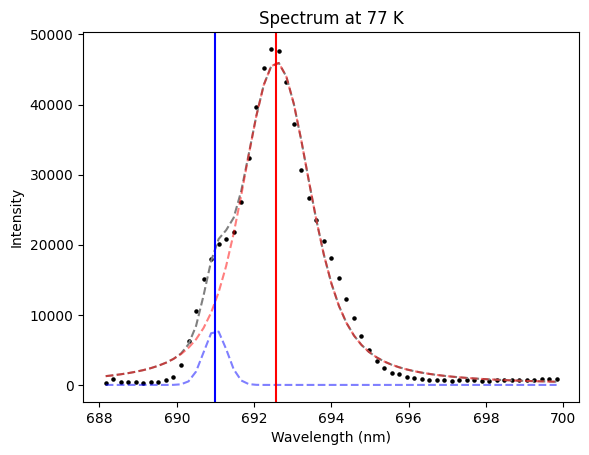

----- Results (77 K) -----
R1 Theory: 693.4
R1 Obs: 692.5770528592866 ± 0.09470124542493077
R1 frac: 0.9561655408347849
R2 Theory: 692.9
R2 Obs: 691.0000000000001 ± 0.07013954160149793
R2 frac: 0.043834459165215015
Reduced Chi Squared: 516.8066042981626


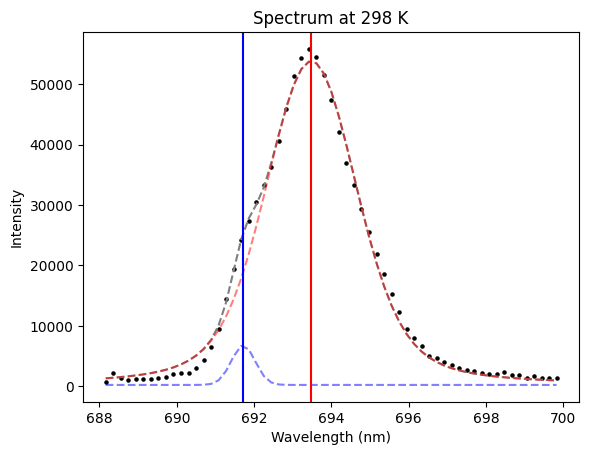

----- Results (298 K) -----
R1 Theory: 693.4
R1 Obs: 693.4803603266727 ± 0.0749828538820013
R1 frac: 0.9731812426014268
R2 Theory: 692.9
R2 Obs: 691.7198296882833 ± 0.05539007831232963
R2 frac: 0.026818757398573142
Reduced Chi Squared: 206.17781154453448


In [29]:
column_names = [
    ["W_77","I_77"],
    ["W_298","I_298"]
]

center1_guesses = {
    77: 691,
    298: 692
}

results = OOA.analyze_ruby_spectra(
    "Ocean_Opt_test.xlsx",
    column_names,
    center1_guesses=center1_guesses
)

In [30]:
print(results)

{77: {'R1_obs': np.float64(692.5770528592866), 'R1_err': np.float64(0.09470124542493077), 'R1_frac': np.float64(0.9561655408347849), 'R2_obs': np.float64(691.0000000000001), 'R2_err': np.float64(0.07013954160149793), 'R2_frac': np.float64(0.043834459165215015), 'reduced_chi2': np.float64(516.8066042981626), 'parameters': array([5.88762544e+03, 6.91000000e+02, 3.34509242e-25, 2.96960535e-01,
       1.28427376e+05, 1.57705286e+00, 5.74230429e-01, 5.90540545e-01,
       2.61302737e-27]), 'covariance': array([[ 2.05803645e+07,  1.13378046e+02,  1.99030086e+03,
        -8.15988618e+02, -2.88950671e+07,  9.71558454e+00,
        -2.40806379e+02,  4.64624865e+01,  3.81031656e+05],
       [ 1.13378046e+02,  4.91955530e-03,  9.29671609e-03,
        -3.17736142e-03, -2.30335790e+01, -3.91620816e-03,
         1.93430052e-03, -2.50294505e-03, -4.83486061e+00],
       [ 1.99030086e+03,  9.29671609e-03,  2.24734865e-01,
        -1.02787716e-01, -2.60700245e+03,  1.40796597e-03,
        -2.26351718e-0

In [37]:
temperatures = [77,298]
Td_fixed = 760
T_fit = np.arange(77,300,0.1)

R1_vals = []
R1_errs = []
R2_vals = []
R2_errs = []

for temp in temperatures:
    R1_vals.append(results[temp]["R1_obs"])
    R1_errs.append(results[temp]["R1_err"])
    R2_vals.append(results[temp]["R2_obs"])
    R2_errs.append(results[temp]["R2_err"])

R1_vals = np.array(R1_vals)
R1_errs = np.array(R1_errs)
R2_vals = np.array(R2_vals)
R2_errs = np.array(R2_errs)

C:\Users\sebas\AppData\Local\Temp\ipykernel_8880\2883333439.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_R1, pcov_R1 = curve_fit(
C:\Users\sebas\AppData\Local\Temp\ipykernel_8880\2883333439.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_R2, pcov_R2 = curve_fit(


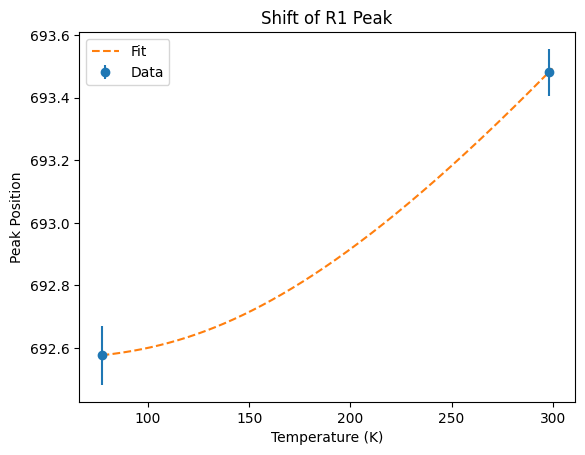

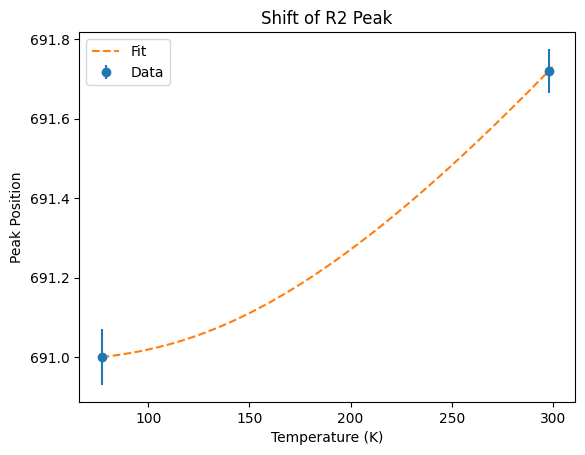

In [38]:
popt_R1, pcov_R1 = curve_fit(
    ruby_shift_model_fixed,
    temperatures,
    R1_vals,
    p0=[R1_vals[0], 1.0]
)

popt_R2, pcov_R2 = curve_fit(
    ruby_shift_model_fixed,
    temperatures,
    R2_vals,
    p0=[R2_vals[0], 1.0]
)


plt.figure(1)
plt.errorbar(temperatures, R1_vals, yerr=R1_errs, fmt='o', label="Data")
plt.plot(T_fit, ruby_shift_model_fixed(T_fit, *popt_R1), '--', label="Fit")
plt.xlabel("Temperature (K)")
plt.ylabel("Peak Position")
plt.title("Shift of R1 Peak")
plt.legend()
plt.show()


plt.figure(1)
plt.errorbar(temperatures, R2_vals, yerr=R2_errs, fmt='o', label="Data")
plt.plot(T_fit, ruby_shift_model_fixed(T_fit, *popt_R2), '--', label="Fit")
plt.xlabel("Temperature (K)")
plt.ylabel("Peak Position")
plt.title("Shift of R2 Peak")
plt.legend()
plt.show()